In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
import matplotlib.pyplot as plt
import seaborn as sns

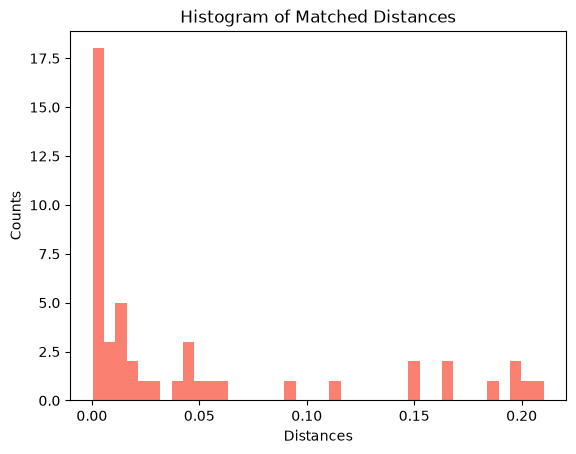

In [24]:
# Question 1.1 Answer

from sklearn.neighbors import NearestNeighbors

# Reading in data
data = pd.read_csv('homework_1.2.csv')

# Creating nearest neighbors model
nbrs = NearestNeighbors(n_neighbors = 1)

# Getting control and treated data
X_0 = data[data['X'] == 0]
X_1 = data[data['X'] == 1]

# Fitting the model to the control 0
nbrs.fit(X_0[['Z']])

# Calculating the match distances and indices
distances, indices = nbrs.kneighbors(X_1[['Z']])

# Plotting the distances on a histogram 
plt.hist(distances, bins = 40, color = 'salmon')
plt.title('Histogram of Matched Distances')
plt.xlabel('Distances')
plt.ylabel('Counts')

plt.show()

In [23]:
summary = pd.DataFrame(distances, columns = ['Distances'])

summary.describe()

,Distances
count,48.000000
mean,0.049788
std,0.068388
min,0.000389
25%,0.002509
50%,0.013260
75%,0.055794
max,0.210217


In [3]:
# Question 2.2 Answer

# Creating pareto distribution
pareto = np.random.pareto(a = 2, size = 10000)

# List of Sample Sizes
full_size = [10, 50, 100, 250, 500, 1000, 2500, 5000, 10000]

# Loop for bootstrapping, starts by looping through sample size list
for i in full_size:
    
    sample_means = []

    # Bootstrapping list that will create random samples and take the mean of it, loops 1000 times
    for x in range(1000):

        # Create random sample from pareto distribution based on the sample size stored in i
        sample = np.random.choice(pareto, size = i)

        # Append mean of sample to sample means list
        sample_means.append(np.mean(sample))

    # Take the variance of the sample means list
    variance = np.var(sample_means)

    # Display the sample variance for the sample size
    print(f"The sample variance for sample size {i} is {variance :.4f}.")



The sample variance for sample size 10 is 0.9618.
The sample variance for sample size 50 is 0.1147.
The sample variance for sample size 100 is 0.0914.
The sample variance for sample size 250 is 0.0316.
The sample variance for sample size 500 is 0.0158.
The sample variance for sample size 1000 is 0.0076.
The sample variance for sample size 2500 is 0.0030.
The sample variance for sample size 5000 is 0.0016.
The sample variance for sample size 10000 is 0.0008.


In [48]:
# Question 3.2 Answer

# Creating Data
plant_data = pd.DataFrame({'group' : [0] * 50 + [1] * 50})

# Duplicating rows in plant_data for before and after treatment
# Ensures the before and after heights for each plant are together
plant_data = plant_data.loc[plant_data.index.repeat(2)].reset_index()
plant_data['time'] = [0, 1] * 100
plant_data['treated'] = plant_data['group'] * plant_data['time']

# Generating starting heights
starting_heights = np.random.normal(10, 2, 100)
plant_data['height'] = np.repeat(starting_heights, 2)

# Adding normal plant growth and treatment plant growth
plant_data['height'] += 5 * plant_data['time']
plant_data['height'] += 5 * plant_data['treated']

X = plant_data[['group', 'time', 'treated']]
y = plant_data['height']

model = sm.OLS(y, X).fit()

model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                                 OLS Regression Results                                
=======================================================================================
Dep. Variable:                 height   R-squared (uncentered):                   0.867
Model:                            OLS   Adj. R-squared (uncentered):              0.865
Method:                 Least Squares   F-statistic:                              426.7
Date:                Fri, 09 Oct 2026   Prob (F-statistic):                    6.93e-86
Time:                        00:25:58   Log-Likelihood:                         -618.58
No. Observations:                 200   AIC:                                      1243.
Df Residuals:                     197   BIC:                                      1253.
Df Model:                           3                                                  
Covariance Type:            nonrobust                                                  
==============================================================================
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
group         10.2339      0.760     13.466      0.000       8.735      11.733
time          15.0042      0.760     19.743      0.000      13.506      16.503
treated       -5.0042      1.316     -3.802      0.000      -7.600      -2.408
==============================================================================
Omnibus:                       24.168   Durbin-Watson:                   1.850
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               27.772
Skew:                           0.878   Prob(JB):                     9.32e-07
Kurtosis:                       2.502   Cond. No.                         3.73
==============================================================================

Notes:
[1] R² is computed without centering (uncentered) since the model does not contain a constant.
[2] Standard Errors assume that the covariance matrix of the errors is correctly specified.
"""

In [52]:
model.pvalues['treated']

np.float64(0.000191537438313806)

In [4]:
# Question 4.1 Answer

data1 = pd.read_csv('homework_4.1.csv')

# Splitting W variable into bins
data1['w_range'] = pd.cut(data1['W'], bins = 10)

effects = []

# Looping through groups based on the W bin
for w_range, group in data1.groupby('w_range', observed = True):

    # Calculating Y mean
    y_mean1 = group.loc[group['Z'] == 1, 'Y'].mean()
    y_mean0 = group.loc[group['Z'] == 0, 'Y'].mean()

    # Calculating X mean
    x_mean1 = group.loc[group['Z'] == 1, 'X'].mean()
    x_mean0 = group.loc[group['Z'] == 0, 'X'].mean()

    # Calculating y and x difference
    y_diff = y_mean1 - y_mean0
    x_diff = x_mean1 - x_mean0

    # Checking to ensure x and y are not NA and X is not 0
    if x_diff != 0 and pd.notna(x_diff) and pd.notna(y_diff): 

        # Calculating effect
        effect = y_diff/x_diff

        effects.append(effect)

# Calculating overall effect
overall_effect = np.mean(effects)

print(f"The overall mean for the second task is {overall_effect :.2f}.")

The overall mean for the second task is 0.91.


In [5]:
# Question 4.2 Answer

data2 = pd.read_csv('homework_4.2.a.csv')
data3 = pd.read_csv('homework_4.2.b.csv')

display(data2.head())
display(data3.head())

,X,Y
0,81.822339,1
1,92.487870,0
2,85.372460,0
3,78.828025,0
4,75.807080,1


,X2,Y2
0,76.643034,1
1,87.743397,1
2,81.639469,1
3,73.740485,0
4,90.480268,1


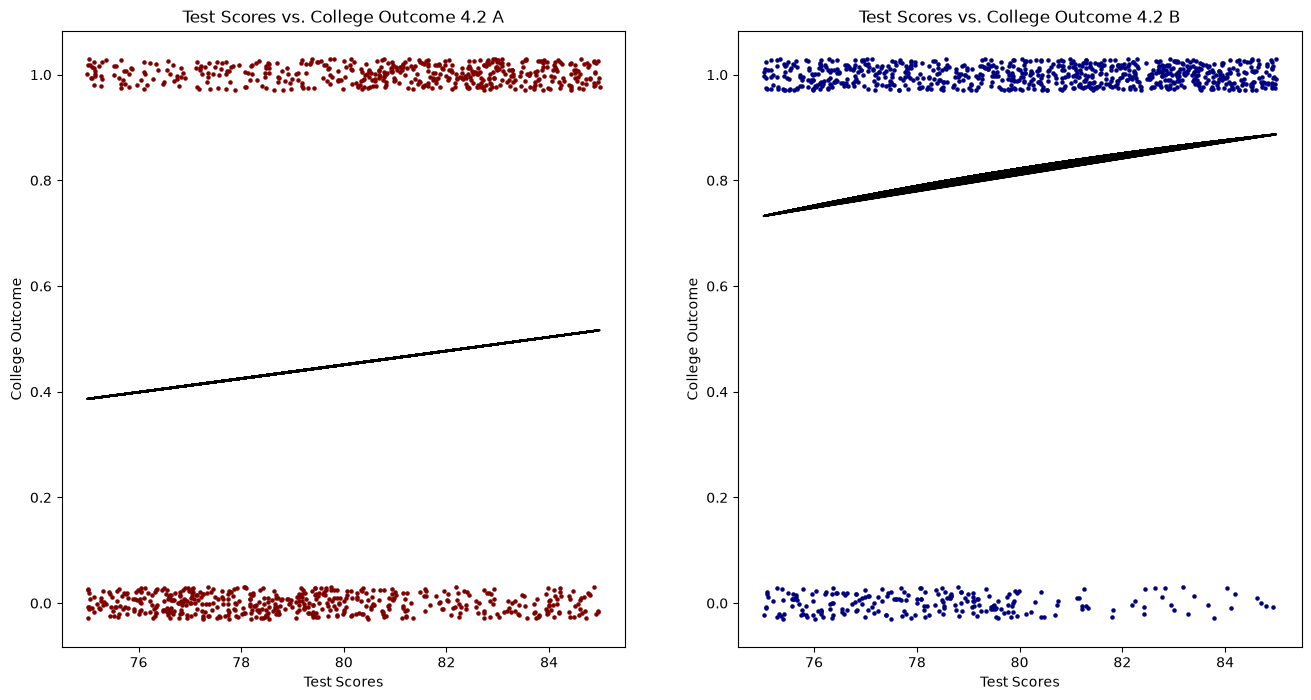

In [6]:
from sklearn.linear_model import LogisticRegression

# Constructing and fitting models
model1 = LogisticRegression()
model1.fit(data2[['X']], data2['Y'])

model2 = LogisticRegression()
model2.fit(data3[['X2']], data3['Y2'])

# Only getting data that has test scores between 75 and 85
data2_plot = data2[(data2['X'] >= 75) & (data2['X'] <= 85)].copy()
data3_plot = data3[(data3['X2'] >= 75) & (data3['X2'] <= 85)].copy()

# Randomly sampling 1000 points so charts can be interpretted
data2_plot = data2_plot.sample(n = 1000, random_state = 42)
data3_plot = data3_plot.sample(n = 1000, random_state = 42)

# Constructing a jitter so the y points are not stacked on top of each other
y_jitter1 = data2_plot['Y'] + np.random.uniform(-0.03, 0.03, len(data2_plot))
y_jitter2 = data3_plot['Y2'] + np.random.uniform(-0.03, 0.03, len(data3_plot))

# Getting probabilities for both data
y_probs1 = model1.predict_proba(data2_plot[['X']])[:, 1]
y_probs2 = model2.predict_proba(data3_plot[['X2']])[:, 1]

# Plotting the scatter plots with the line of y probabilities
fig, ax = plt.subplots(1, 2, figsize = (16, 8))

ax[0].scatter(data2_plot['X'], y_jitter1, s = 5, color = 'maroon')
ax[0].plot(data2_plot['X'], y_probs1, color = 'black')
ax[0].set_title('Test Scores vs. College Outcome 4.2 A')
ax[0].set_xlabel('Test Scores')
ax[0].set_ylabel('College Outcome')

ax[1].scatter(data3_plot['X2'], y_jitter2, s = 5, color = 'navy')
ax[1].plot(data3_plot['X2'], y_probs2, color = 'black')
ax[1].set_title('Test Scores vs. College Outcome 4.2 B')
ax[1].set_xlabel('Test Scores')
ax[1].set_ylabel('College Outcome')

plt.show()